In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# SD/CN dependencies
!pip install --upgrade diffusers transformers accelerate safetensors torch torchvision torchaudio numpy scipy pillow opencv-python matplotlib tqdm einops omegaconf huggingface_hub ftfy sentencepiece xformers controlnet_aux opencv-python hf_xet

In [ ]:
# Import all required libraries
import torch
from diffusers import StableDiffusionXLPipeline, StableDiffusionXLControlNetPipeline, ControlNetModel, MultiControlNetModel, DDIMScheduler, EulerAncestralDiscreteScheduler, AutoencoderKL
from transformers import CLIPImageProcessor
from PIL import Image
import numpy as np
import cv2

# Free Memory
torch.cuda.empty_cache()

In [ ]:
# Set up processing device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Allocate paths
folder_name = "refract"

image_render_path = "/content/drive/MyDrive/inputs-" + folder_name + "/Render.png"
image_normal_path = "/content/drive/MyDrive/inputs-" + folder_name + "/NormalMap.png"
image_depth_path = "/content/drive/MyDrive/inputs-" + folder_name + "/DepthMap.png"
image_shadow_path = "/content/drive/MyDrive/inputs-" + folder_name + "/ShadowMap.png"

image_reflection_path = "/content/drive/MyDrive/inputs-refract/ReflectionMap.png"
image_refraction_path = "/content/drive/MyDrive/inputs-refract/RefractionMap.png"

In [ ]:
# 1. ControlNet-SDXL models + MultiControlNet model
cnxl_canny = ControlNetModel.from_pretrained("xinsir/controlnet-canny-sdxl-1.0", torch_dtype=torch.float16)
cnxl_depth = ControlNetModel.from_pretrained("xinsir/controlnet-depth-sdxl-1.0", torch_dtype=torch.float16)
cnxl_tile = ControlNetModel.from_pretrained("xinsir/controlnet-tile-sdxl-1.0", torch_dtype=torch.float16)

cnxlnets = MultiControlNetModel([cnxl_canny, cnxl_depth, cnxl_tile, cnxl_tile])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

In [ ]:
# 2. Scheduler
eulera_scheduler = EulerAncestralDiscreteScheduler.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", subfolder="scheduler")

In [ ]:
# 3. VAE model
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)

config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [ ]:
# 4. Load ControlNet Pipeline
pipelnSD = StableDiffusionXLControlNetPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0",
                                                             controlnet=cnxlnets,
                                                             #vae=vae,
                                                             # safety_checker = False,
                                                             #scheduler = eulera_scheduler,
                                                             torch_dtype=torch.float16).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
# Simple Canny function
def cannier(img, lo, hi):
  image = np.array(img)
  image = cv2.Canny(image, lo, hi)
  image = image[:, :, None]
  image = np.concatenate([image, image, image], axis=2)
  return Image.fromarray(image)

In [ ]:
# Better Canny function
def big_cannier(img, low_threshold=100, high_threshold=150, kernel_size=1, blur_strength = 5):
    # Convert PIL to numpy if needed
    if isinstance(img, Image.Image):
        img = np.array(img)

    # Step 1: Convert to grayscale

    # Step 2: Apply bilateral filter (edge-preserving noise reduction)
    # This preserves edges better than Gaussian blur alone
    denoised = cv2.bilateralFilter(img, 9, 75, 75)

    # Step 4: Apply Canny edge detection
    edges = cv2.Canny(denoised, low_threshold, high_threshold)

    # Step 5: Morphological operations to clean up the edges
    # Create a kernel for morphological operations
    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    # Dilate to connect broken edge lines
    edges = cv2.dilate(edges, kernel, iterations=1)

    # Erode to thin edges
    edges = cv2.erode(edges, kernel, iterations=1)

    # Step 6: Convert back to RGB
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

    # Return as PIL Image
    return Image.fromarray(edges_rgb)

In [ ]:
# Load image
main_render = Image.open(image_render_path).convert("RGB")
# Load maps
depth_image = Image.open(image_depth_path).convert("RGB")
normal_image = Image.open(image_normal_path).convert("RGB")
shadow_image = Image.open(image_shadow_path).convert("RGB")

reflect_image = Image.open(image_reflection_path).convert("RGB")
refract_image = Image.open(image_refraction_path).convert("RGB")

# Canny Map
canny_main = big_cannier(img=main_render, blur_strength=13).convert("RGB")
canny_ref = big_cannier(img=refract_image, blur_strength=13).convert("RGB")

In [ ]:
def combine_canny_maps(image1, image2):
    # Load the images
    img1 = image1.convert('L')  # Convert to grayscale
    img2 = image2.convert('L')  # Convert to grayscale

    # Ensure both images are the same size
    if img1.size != img2.size:
        img2 = img2.resize(img1.size)

    # Convert to numpy arrays for easier manipulation
    img1_array = np.array(img1)
    img2_array = np.array(img2)

    # Combine the edge maps using maximum values at each pixel
    # (You can also use other methods like weighted average)
    combined_array = np.maximum(img1_array, img2_array)

    # Convert back to PIL Image
    combined_image = Image.fromarray(combined_array)

    return combined_image

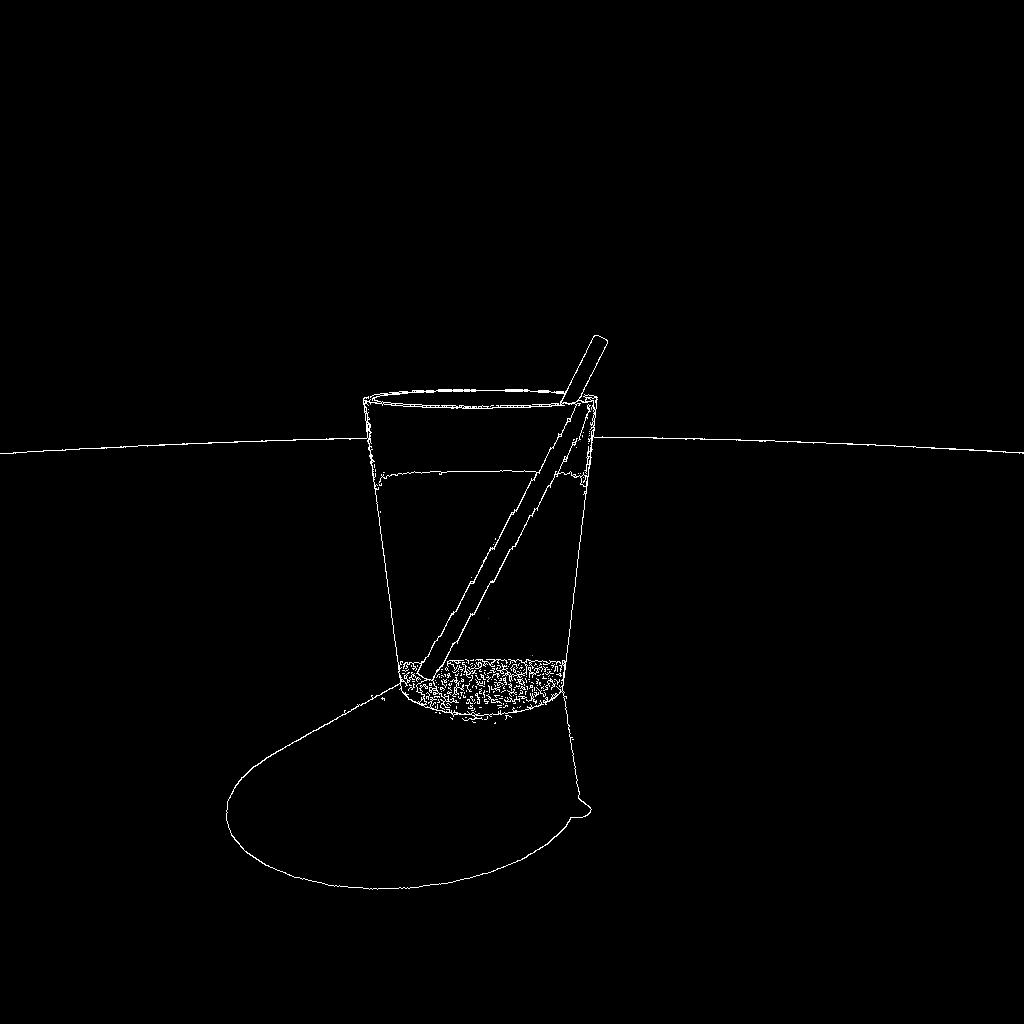

In [ ]:
canny_main

combined_map = combine_canny_maps(canny_main, canny_ref)

canny_map = combined_map.convert("RGB")

canny_map = Image.open("3333.png").convert("RGB")

canny_map.resize([1024,1024])


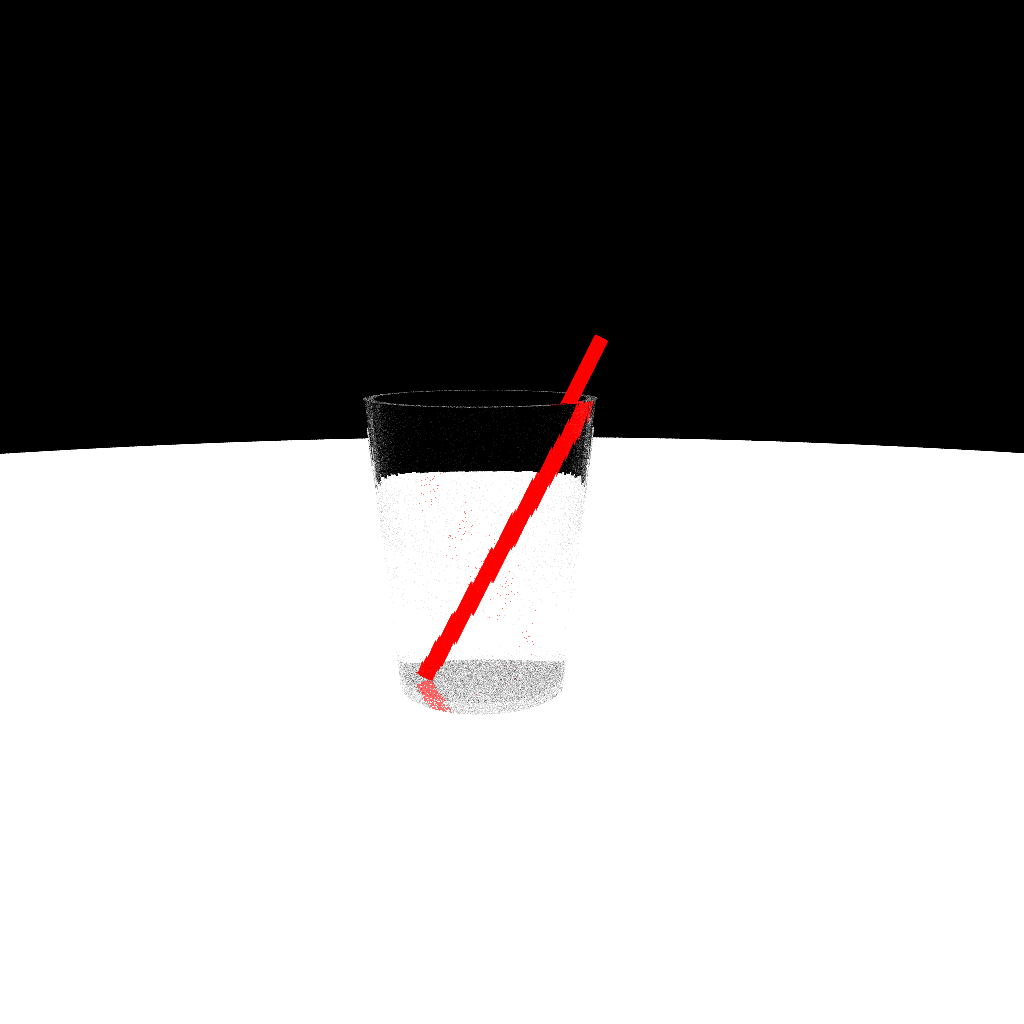

In [ ]:
refract_image

In [ ]:
# Output/Scoring settings
prompt = "A photorealistic image of a green glass with a red straw on a white surface. The glass is casting a dark shadow. The background is a blue sky. The straw and background are refracted in the glass."
negative_prompt = "cartoon, drawn, blurry, abstract, liquid, glow"
seed = 72

  0%|          | 0/100 [00:00<?, ?it/s]

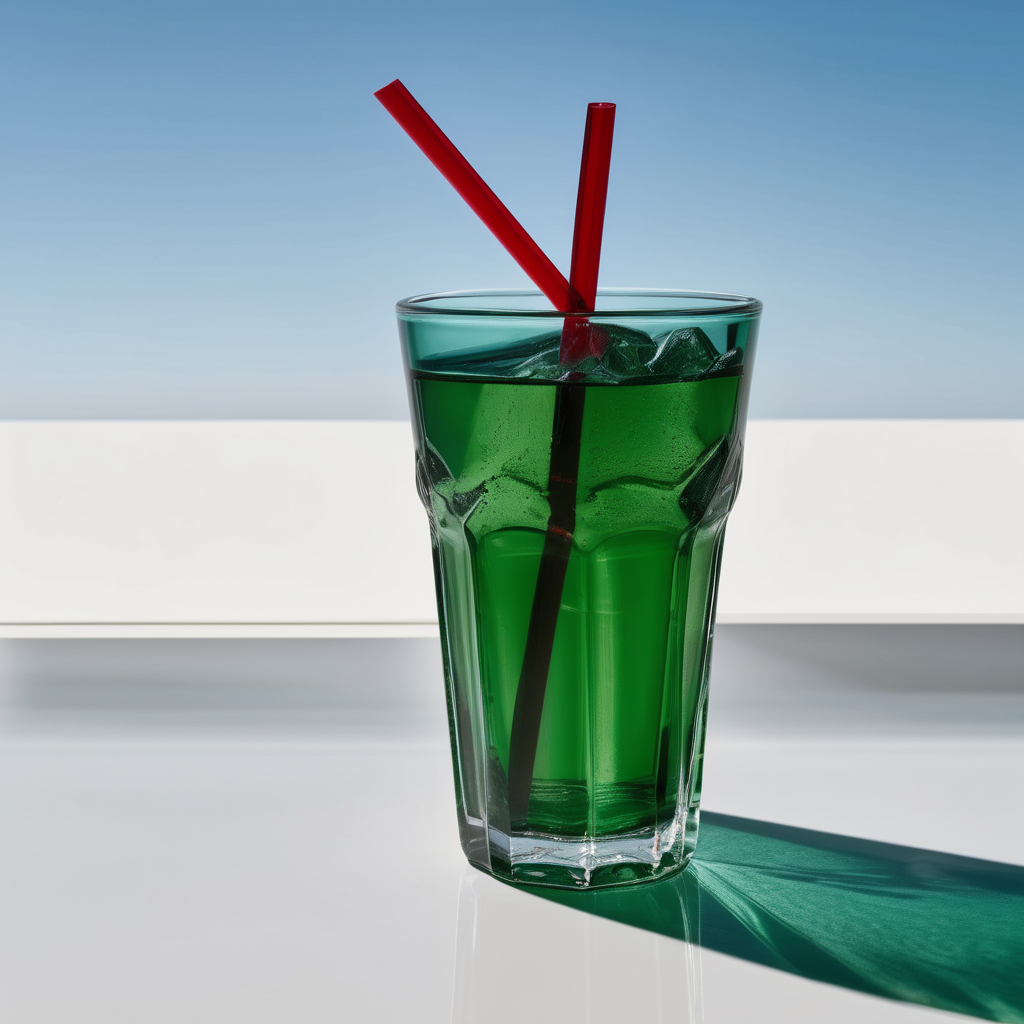

In [ ]:
# Generate output - SD
output = pipelnSD(
    prompt = prompt,
    negative_prompt = negative_prompt,
    image = main_render,
    strength = 0.5,
    guidance_scale = 7.5,
    num_inference_steps=100,
    generator=torch.manual_seed(seed)
).images

output[0]

  0%|          | 0/100 [00:00<?, ?it/s]

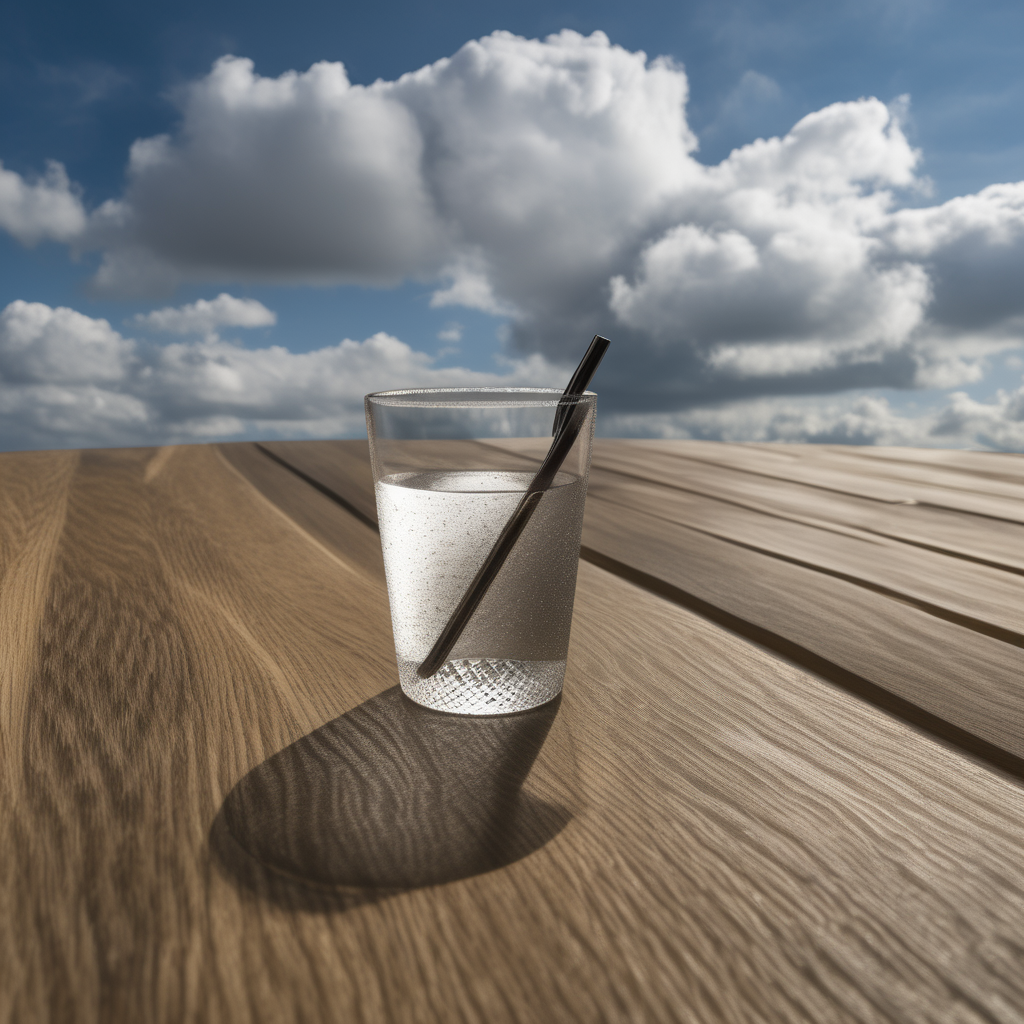

In [ ]:
# Generate output - SD-SCN
output = pipelnSD(
    prompt = prompt,
    negative_prompt = negative_prompt,
    image = canny_map,
    control_image = canny_map,
    controlnet_conditioning_scale = 0.5,
    guidance_scale = 7.5,
    num_inference_steps=100,
    generator=torch.manual_seed(seed)
).images

output[0]

  0%|          | 0/100 [00:00<?, ?it/s]

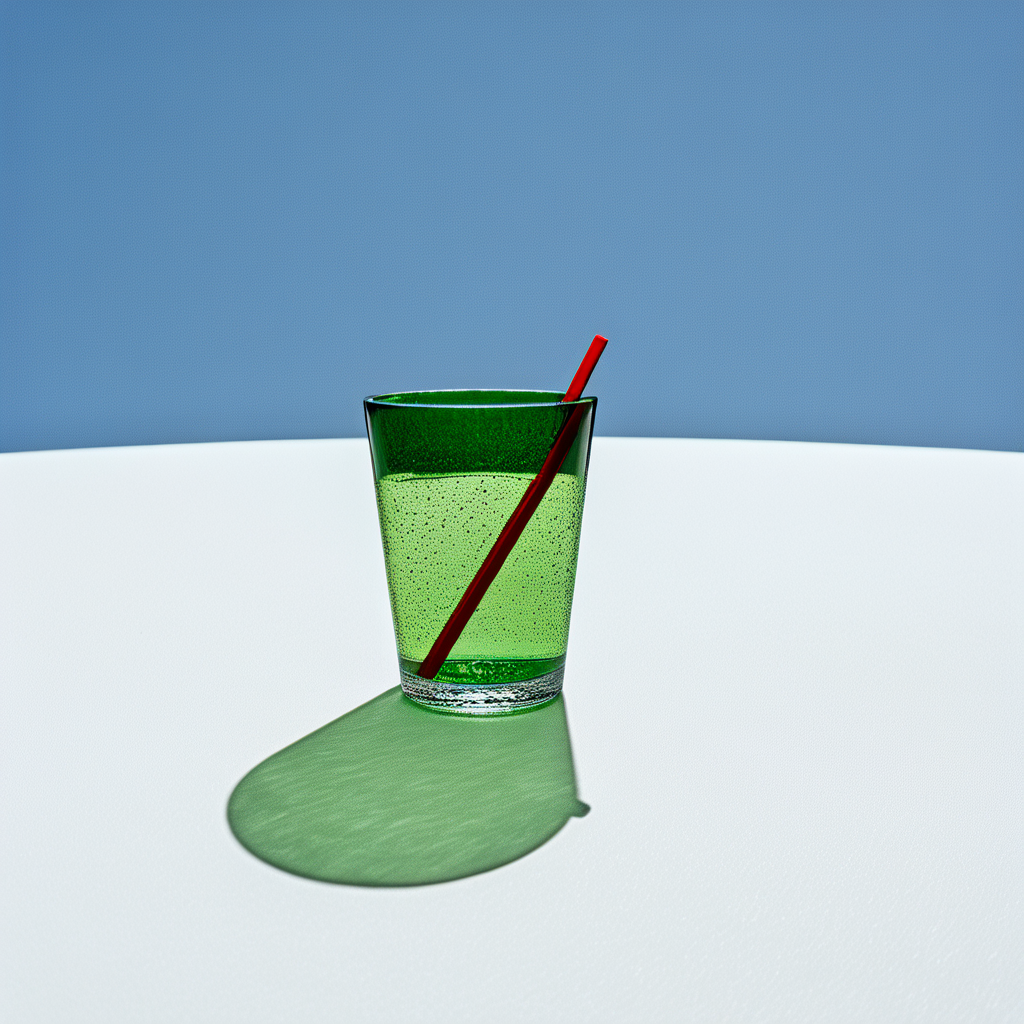

In [ ]:
# Generate output - SD-MCN-D
output = pipelnSD(
    prompt = prompt,
    negative_prompt = negative_prompt,
    image = [canny_main, depth_image, refract_image, shadow_image],
    control_image = [canny_main, depth_image, refract_image, shadow_image],
    controlnet_conditioning_scale = [0.5, 0.5, 0.5, 0.5],
    guidance_scale = 7.5,
    num_inference_steps=100,
    control_guidance_start=[0.0, 0.0, 0.0, 0.0],
    control_guidance_end=[1.0, 1.0, 1.0, 1.0],
    generator=torch.manual_seed(seed)
).images

output[0]

  0%|          | 0/100 [00:00<?, ?it/s]

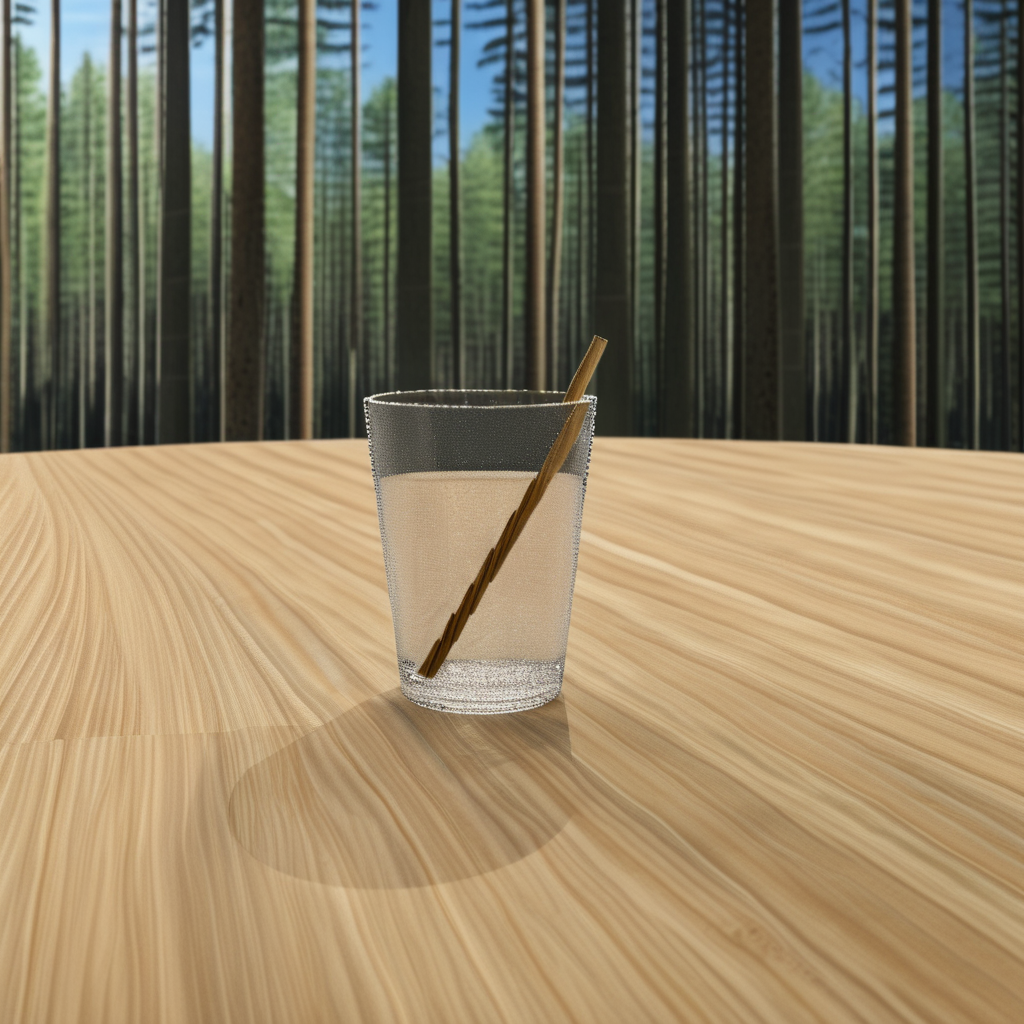

In [ ]:
# Generate output - SD-MCN-N
output = pipelnSD(
    prompt = prompt,
    negative_prompt = negative_prompt,
    image = [canny_map, depth_image, refract_image, shadow_image],
    control_image = [canny_map, depth_image, refract_image, shadow_image],
    controlnet_conditioning_scale=[0.7, 0.5, 0.3, 0.1],
    guidance_scale = 9.5,
    num_inference_steps=100,
    control_guidance_start=[0.0, 0.0, 0.0, 0.0],
    control_guidance_end=[1.0, 0.95, 0.95, 0.8]
    generator=torch.manual_seed(seed)
).images

output[0]